# Rook vs Shrikhande - Δ-DRESS Demo

The **Rook graph** L₂(4) and the **Shrikhande graph** are strongly regular with identical parameters SRG(16, 6, 2, 2). Standard DRESS converges to the same values for both - they are *cospectral*.

**Δ¹-DRESS** (single-vertex deletion) breaks this symmetry: it runs DRESS on every subgraph obtained by removing one vertex, then collects *all* converged edge values into a histogram. The two graphs produce different histograms, proving they are non-isomorphic.

> **TL;DR:** Same SRG parameters, same DRESS spectrum - but Δ-DRESS tells them apart instantly.

In [1]:
# Install dependencies
!pip install -q dress-graph networkx matplotlib numpy

In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from dress.networkx import dress_graph, delta_dress_graph

## 1. Build the two SRG(16, 6, 2, 2) graphs

In [3]:
def build_rook():
    """Rook graph L₂(4) = K₄ □ K₄.  16 vertices, 48 edges."""
    G = nx.Graph()
    for i in range(4):
        for j in range(4):
            u = 4 * i + j
            for k in range(4):
                if k != j:
                    G.add_edge(u, 4 * i + k)
                if k != i:
                    G.add_edge(u, 4 * k + j)
    return G


def build_shrikhande():
    """Shrikhande graph: 4×4 torus + diagonal neighbours.  16 vertices, 48 edges."""
    G = nx.Graph()
    for i in range(4):
        for j in range(4):
            u = 4 * i + j
            for di, dj in [(0, 1), (0, -1), (1, 0), (-1, 0), (1, 1), (-1, -1)]:
                v = 4 * ((i + di) % 4) + ((j + dj) % 4)
                G.add_edge(u, v)
    return G


rook = build_rook()
shri = build_shrikhande()

print(f"Rook:        {rook.number_of_nodes()} nodes, {rook.number_of_edges()} edges")
print(f"Shrikhande:  {shri.number_of_nodes()} nodes, {shri.number_of_edges()} edges")

Rook:        16 nodes, 48 edges
Shrikhande:  16 nodes, 48 edges


## 2. Standard DRESS - identical for both

In [ ]:
res_rook = dress_graph(rook)
res_shri = dress_graph(shri)

ev_rook = np.array(res_rook.edge_dress)
ev_shri = np.array(res_shri.edge_dress)

print(f"Rook  - mean: {ev_rook.mean():.6f},  std: {ev_rook.std():.8f}")
print(f"Shri  - mean: {ev_shri.mean():.6f},  std: {ev_shri.std():.8f}")
print(f"\nStandard DRESS distinguishes them? {not np.array_equal(sorted(ev_rook), sorted(ev_shri))}")

Rook  — mean: 1.215250,  std: 0.00000000
Shri  — mean: 1.215250,  std: 0.00000000

Standard DRESS distinguishes them? False


Both produce *exactly* the same sorted edge-value multiset - DRESS alone cannot tell them apart.

## 3. Δ¹-DRESS - breaks the symmetry

In [5]:
delta_rook = delta_dress_graph(rook, k=1)
delta_shri = delta_dress_graph(shri, k=1)

h_rook = np.array(delta_rook.histogram)
h_shri = np.array(delta_shri.histogram)

# Print raw nonzero histogram entries
epsilon = 1e-6
for label, h in [("Rook", h_rook), ("Shrikhande", h_shri)]:
    nz = np.nonzero(h)[0]
    print(f"\n{label} - {len(nz)} distinct bin(s), {h.sum()} total edge values:")
    for idx in nz:
        print(f"  d = {idx * epsilon:.6f}  ->  count = {h[idx]}")

# Pad to equal length for comparison
max_len = max(len(h_rook), len(h_shri))
h_rook = np.pad(h_rook, (0, max_len - len(h_rook)))
h_shri = np.pad(h_shri, (0, max_len - len(h_shri)))

match = np.array_equal(h_rook, h_shri)
print(f"\nΔ¹-DRESS histograms identical? {match}")
print(f"-> Δ-DRESS distinguishes Rook from Shrikhande!" if not match else "")


Rook — 3 distinct bin(s), 672 total edge values:
  d = 0.991596  →  count = 96
  d = 1.209662  →  count = 288
  d = 1.350236  →  count = 288

Shrikhande — 5 distinct bin(s), 672 total edge values:
  d = 1.081855  →  count = 96
  d = 1.182154  →  count = 96
  d = 1.211156  →  count = 192
  d = 1.323048  →  count = 192
  d = 1.333430  →  count = 96

Δ¹-DRESS histograms identical? False
→ Δ-DRESS distinguishes Rook from Shrikhande!


## 4. Visualise the histograms

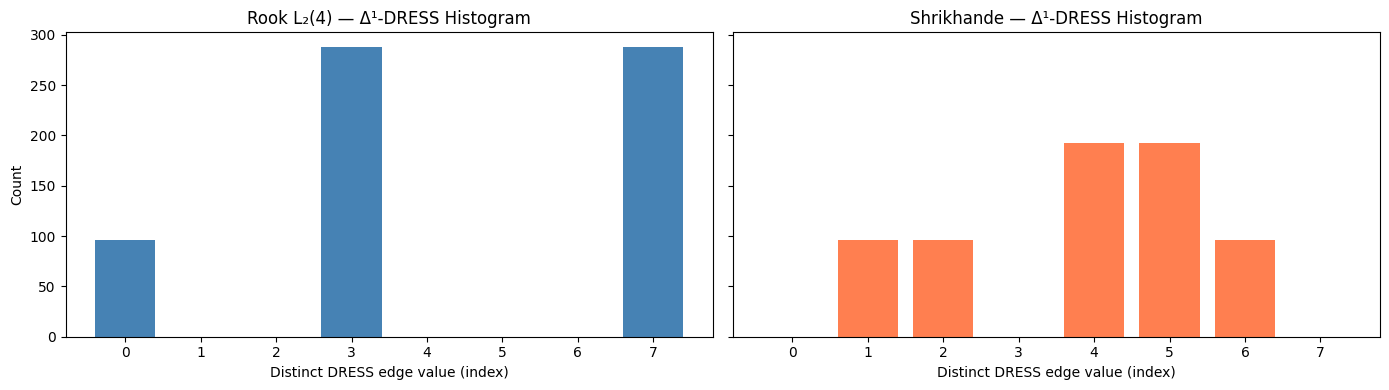


8 distinct bin(s) with nonzero counts
DRESS value range: [0.991596, 1.350236]


In [6]:
epsilon = 1e-6  # default bin width

# Only keep bins where at least one histogram is nonzero
nonzero = np.where((h_rook > 0) | (h_shri > 0))[0]
vals_rook = h_rook[nonzero]
vals_shri = h_shri[nonzero]
x_vals = nonzero * epsilon  # actual DRESS edge values

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].bar(range(len(vals_rook)), vals_rook, color='steelblue')
axes[0].set_title('Rook L₂(4) - Δ¹-DRESS Histogram')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Distinct DRESS edge value (index)')

axes[1].bar(range(len(vals_shri)), vals_shri, color='coral')
axes[1].set_title('Shrikhande - Δ¹-DRESS Histogram')
axes[1].set_xlabel('Distinct DRESS edge value (index)')

plt.tight_layout()
plt.show()

# Print the actual edge values for reference
print(f"\n{len(nonzero)} distinct bin(s) with nonzero counts")
print(f"DRESS value range: [{x_vals[0]:.6f}, {x_vals[-1]:.6f}]")

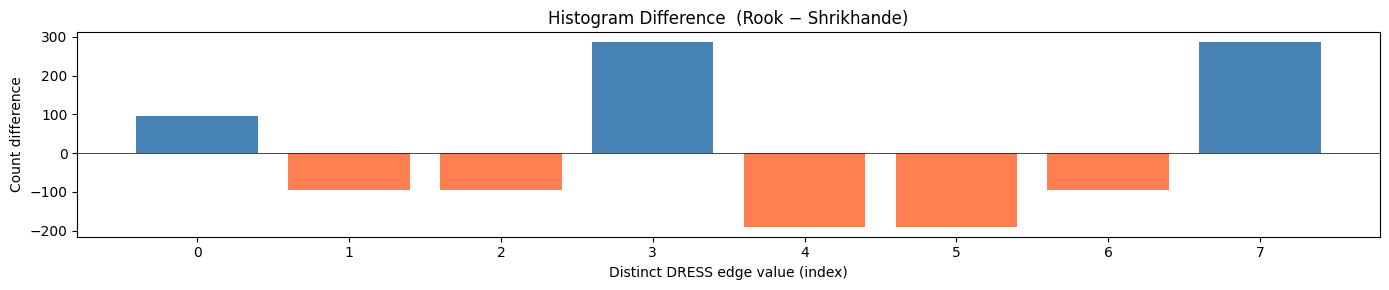

In [7]:
# Overlay difference (only at nonzero positions from above)
diff = vals_rook.astype(int) - vals_shri.astype(int)
nonzero_diff = np.where(diff != 0)[0]

if len(nonzero_diff) > 0:
    d_vals = diff[nonzero_diff]
    colors = ['steelblue' if d > 0 else 'coral' for d in d_vals]

    plt.figure(figsize=(14, 3))
    plt.bar(range(len(d_vals)), d_vals, color=colors)
    plt.axhline(0, color='black', linewidth=0.5)
    plt.title('Histogram Difference  (Rook - Shrikhande)')
    plt.xlabel('Distinct DRESS edge value (index)')
    plt.ylabel('Count difference')
    plt.tight_layout()
    plt.show()
else:
    print("No difference - histograms are identical.")

### What does this show?

The Rook and Shrikhande graphs share the same strongly regular parameters and the same standard DRESS edge-value multiset, yet their **Δ¹-DRESS histograms differ**.

By exhaustively deleting one vertex at a time and aggregating all resulting DRESS edge values, Δ-DRESS captures *finer* structural information that a single-pass DRESS cannot - enough to distinguish these two cospectral mates.